# Flicker (1/f) noise -> oscillator phase noise -> the Allan floor
### why the same $1/f$ that lurks in a transistor sets the ultimate stability of a clock

`dgs/flicker_noise.py` gives us noise with power spectral density $S(f)=A/f^{\alpha}$. This
notebook follows that $1/f$ noise through to the thing engineers actually care about: an
oscillator's **phase noise** and its **Allan deviation**. The chain is:

1. **Colors of noise** -- white ($\alpha=0$), pink ($\alpha=1$), brown ($\alpha=2$) look and
   spectrally *are* different.
2. **Equal power per octave** -- the defining fingerprint of $1/f$, proven symbolically.
3. **Phase noise** -- an oscillator integrates its frequency noise into phase, so device
   flicker noise becomes a steep $f^{-3}$ skirt close to the carrier.
4. **Allan deviation** -- white frequency noise averages away as $\tau^{-1/2}$, but flicker
   noise leaves a **flat floor** you cannot average out. That floor is the clock's limit.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import flicker_noise as fn
print("colors (alpha):", fn.NOISE_COLORS)

colors (alpha): {'violet': -2.0, 'blue': -1.0, 'white': 0.0, 'pink': 1.0, 'brown': 2.0}


## 1. The colors of noise

Same variance, completely different character. White noise is uncorrelated hash; pink noise
wanders with structure at every scale; brown noise (a random walk) drifts. On a log-log
periodogram each is a straight line of slope $-\alpha$.

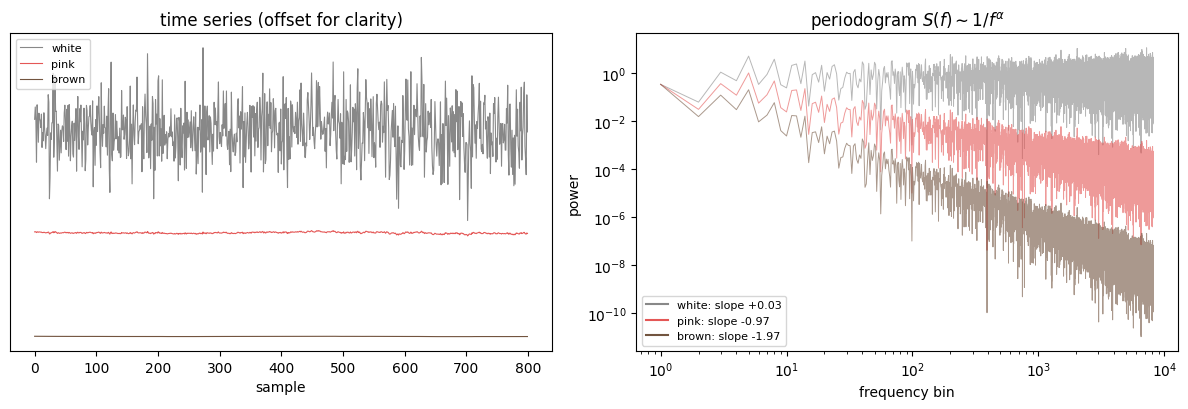

In [2]:
N = 2**14
fig, (axt, axp) = plt.subplots(1, 2, figsize=(12, 4.2))
for color, a, c in [("white", 0.0, "#888"), ("pink", 1.0, "#E45756"), ("brown", 2.0, "#72543f")]:
    x = fn.generate_colored_noise(N, alpha=a, seed=1)
    axt.plot(x[:800] + 4*(1-a), lw=0.8, color=c, label=color)
    f, psd = fn.periodogram(x)
    axp.loglog(f, psd, lw=0.7, color=c, alpha=0.6)
    slope = fn.estimate_psd_slope(x)
    axp.plot([], [], color=c, label=f"{color}: slope {slope:+.2f}")
axt.set_title("time series (offset for clarity)"); axt.set_xlabel("sample"); axt.legend(fontsize=8)
axt.set_yticks([])
axp.set_title("periodogram $S(f)\\sim 1/f^{\\alpha}$"); axp.set_xlabel("frequency bin")
axp.set_ylabel("power"); axp.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. Equal power per octave -- the fingerprint of $1/f$

Integrate the PSD over a band: $\int_{f_1}^{f_2} A/f\,df = A\ln(f_2/f_1)$, which depends only
on the **ratio**. So every octave $[f,2f]$ of pink noise holds the same power $A\ln 2$. White
noise (flat) instead *doubles* its power each octave (twice the bandwidth), and brown noise
*falls*. SymPy confirms the octave power is $A\ln 2$ with no $f_1$ left in it.

integral of A/f over [f1,f2] : log((f2/f1)**A)
power in any octave [f,2f]   : A*log(2)  (no f1 -> equal per octave)


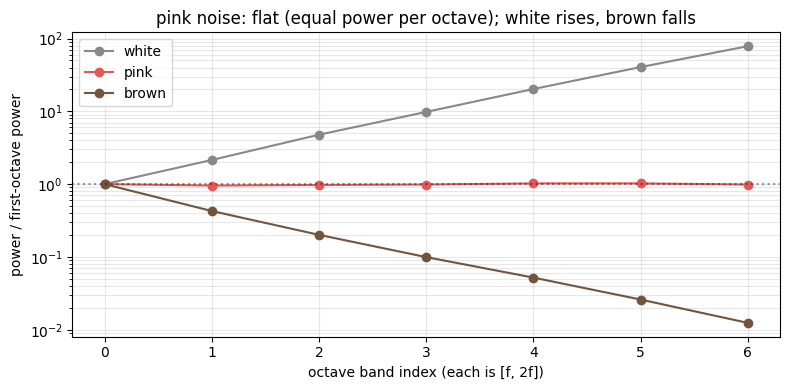

In [3]:
band, octave = fn.symbolic_band_power()
print("integral of A/f over [f1,f2] :", band)
print("power in any octave [f,2f]   :", octave, " (no f1 -> equal per octave)")

# measure power in successive octave bands for each color
def octave_powers(x, n_oct=7):
    f, psd = fn.periodogram(x)
    out = []
    for k in range(n_oct):
        lo, hi = 2.0**(k+1), 2.0**(k+2)
        out.append(psd[(f >= lo) & (f < hi)].sum())
    return np.array(out)

N = 2**16
oct_idx = np.arange(7)
plt.figure(figsize=(8, 4))
for color, a, c in [("white", 0.0, "#888"), ("pink", 1.0, "#E45756"), ("brown", 2.0, "#72543f")]:
    p = np.mean([octave_powers(fn.generate_colored_noise(N, a, s)) for s in range(10)], axis=0)
    plt.semilogy(oct_idx, p / p[0], "o-", color=c, label=color)
plt.axhline(1.0, color="k", ls=":", alpha=0.4)
plt.xlabel("octave band index (each is [f, 2f])"); plt.ylabel("power / first-octave power")
plt.title("pink noise: flat (equal power per octave); white rises, brown falls")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

## 3. From device noise to oscillator phase noise

An oscillator's output is $\cos(2\pi f_0 t + \phi(t))$. Its **fractional frequency** fluctuates
with some noise $y(t)$, and the **phase** is the running integral $\phi(t)=2\pi\!\int y\,dt$.
Integration multiplies the PSD by $1/f^2$, so:

* **white** frequency noise ($y$ flat) $\to$ phase noise $S_\phi\sim f^{-2}$,
* **flicker** frequency noise ($y\sim 1/f$) $\to$ phase noise $S_\phi\sim f^{-3}$.

That $f^{-3}$ skirt hugging the carrier is the up-converted $1/f$ device noise -- the dominant
close-in phase noise of real oscillators (the steep part of a Leeson plot).

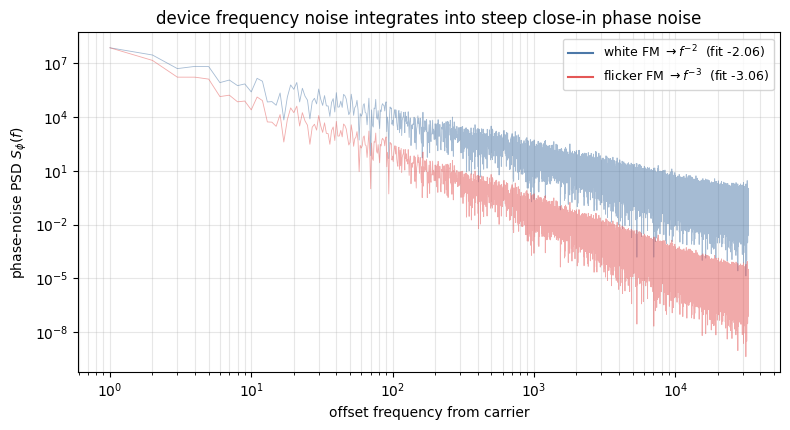

In [4]:
N = 2**16
dt = 1.0
fig, ax = plt.subplots(figsize=(8, 4.4))
for label, a, target, c in [("white FM $\\to f^{-2}$", 0.0, -2, "#4C78A8"),
                            ("flicker FM $\\to f^{-3}$", 1.0, -3, "#E45756")]:
    y = fn.generate_colored_noise(N, alpha=a, seed=7)      # fractional frequency noise
    phase = np.cumsum(y) * dt                              # phi = 2pi int y dt (2pi absorbed)
    phase -= phase.mean()
    f, psd = fn.periodogram(phase)
    ax.loglog(f, psd, lw=0.6, color=c, alpha=0.5)
    sl = fn.estimate_psd_slope(phase, 0.002, 0.05)         # close-in slope
    ax.plot([], [], color=c, label=f"{label}  (fit {sl:+.2f})")
ax.set_xlabel("offset frequency from carrier"); ax.set_ylabel("phase-noise PSD $S_\\phi(f)$")
ax.set_title("device frequency noise integrates into steep close-in phase noise")
ax.legend(fontsize=9); ax.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

## 4. Allan deviation -- the floor $1/f$ noise leaves behind

To measure clock stability you average frequency over a gate time $\tau$ and ask how much
adjacent averages differ: the **Allan deviation**
$$\sigma_y(\tau)=\sqrt{\tfrac12\langle(\bar y_{k+1}-\bar y_k)^2\rangle}.$$
For **white** frequency noise, longer averaging helps: $\sigma_y\propto\tau^{-1/2}$ (slope
$-1/2$). For **flicker** ($1/f$) frequency noise it **stops helping** -- $\sigma_y(\tau)$ goes
flat. That flicker floor is the fundamental stability limit; you cannot average a $1/f$ process
away, which is exactly why it dominates precision oscillators, and it's the phase-noise budget
that matters for the time-stretch clocking in this repo.

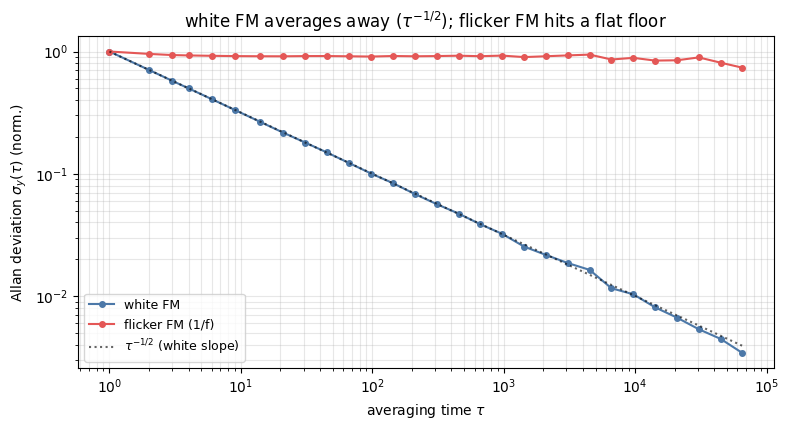

white FM Allan slope : -0.5
flicker Allan slope  : -0.01  (~0 -> flat floor)


In [5]:
def allan_deviation(y, tau0=1.0, ms=None):
    N = len(y)
    if ms is None:
        ms = np.unique(np.floor(np.logspace(0, np.log10(N//4), 30)).astype(int))
    taus, adev = [], []
    for m in ms:
        K = N // m
        if K < 2:
            continue
        ybar = y[:K*m].reshape(K, m).mean(axis=1)          # average over m samples
        d = np.diff(ybar)
        adev.append(np.sqrt(0.5 * np.mean(d**2)))
        taus.append(m * tau0)
    return np.array(taus), np.array(adev)

N = 2**18
plt.figure(figsize=(8, 4.4))
for color, a, c in [("white FM", 0.0, "#4C78A8"), ("flicker FM (1/f)", 1.0, "#E45756")]:
    ad = np.mean([allan_deviation(fn.generate_colored_noise(N, a, s))[1] for s in range(6)], axis=0)
    taus = allan_deviation(fn.generate_colored_noise(N, a, 0))[0]
    plt.loglog(taus, ad / ad[0], "o-", ms=4, color=c, label=color)
plt.loglog(taus, taus**-0.5, "k:", alpha=0.6, label="$\\tau^{-1/2}$ (white slope)")
plt.xlabel("averaging time $\\tau$"); plt.ylabel("Allan deviation $\\sigma_y(\\tau)$ (norm.)")
plt.title("white FM averages away ($\\tau^{-1/2}$); flicker FM hits a flat floor")
plt.legend(fontsize=9); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()
print("white FM Allan slope :", np.round(np.polyfit(np.log(taus), np.log(
    np.mean([allan_deviation(fn.generate_colored_noise(N,0.0,s))[1] for s in range(6)],axis=0)),1)[0],2))
print("flicker Allan slope  :", np.round(np.polyfit(np.log(taus), np.log(
    np.mean([allan_deviation(fn.generate_colored_noise(N,1.0,s))[1] for s in range(6)],axis=0)),1)[0],2),
    " (~0 -> flat floor)")

## What we did

* The **colors of noise** are straight lines of slope $-\alpha$ on a log-log periodogram; the
  synthesizer in `dgs/flicker_noise.py` reproduces each exactly.
* **Equal power per octave** ($A\ln 2$, no $f_1$) is the symbolic fingerprint of $1/f$; pink
  noise's octave-power bars are flat while white rises and brown falls.
* An oscillator **integrates** frequency noise into phase, turning device $1/f$ (flicker FM)
  into an $f^{-3}$ close-in **phase-noise** skirt.
* **Allan deviation** shows why it matters: white noise averages away as $\tau^{-1/2}$, but the
  flicker floor is *flat* -- the irreducible limit on clock stability.

Ties to `dgs/snr.py` and `dgs/adc_snr_bits.py` (the noise floor that caps a receiver's bit
depth) and to the time-stretch clocking behind the dispersion-GS pipeline.

**Next thread:** the time-independent Schrodinger equation and the admissibility conditions on
$\psi(x)$ -- finite everywhere (including $x\to\pm\infty$), single-valued, continuous, with
continuous slope wherever $U(x)$ is finite -- which force plane-wave vs. wave-packet behavior
and, for confined states, **quantization**.